In [ ]:
import pandas as pd
import numpy as np

#1. Upload the Spotify file

In [ ]:
from google.colab import files
uploaded = files.upload() #upload the file directly

Saving spotify-data.csv to spotify-data.csv


# 2. Let's visualize the Spotify as DataFrame

In [ ]:
df = pd.read_csv('/content/spotify-data.csv')
df.head()

,id,name,artists,duration_ms,release_date,year,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,mode,key,popularity,explicit
0,6KbQ3uYMLKb5jDxLF7wYDD,Singende Bataillone 1. Teil,['Carl Woitschach'],158648,1928,1928,0.995,0.708,0.1950,0.563,0.1510,-12.428,0.0506,118.469,0.7790,1,10,0,0
1,6KuQTIu1KoTTkLXKrwlLPV,"Fantasiestücke, Op. 111: Più tosto lento","['Robert Schumann', 'Vladimir Horowitz']",282133,1928,1928,0.994,0.379,0.0135,0.901,0.0763,-28.454,0.0462,83.972,0.0767,1,8,0,0
2,6L63VW0PibdM1HDSBoqnoM,Chapter 1.18 - Zamek kaniowski,['Seweryn Goszczyński'],104300,1928,1928,0.604,0.749,0.2200,0.000,0.1190,-19.924,0.9290,107.177,0.8800,0,5,0,0
3,6M94FkXd15sOAOQYRnWPN8,Bebamos Juntos - Instrumental (Remasterizado),['Francisco Canaro'],180760,9/25/28,1928,0.995,0.781,0.1300,0.887,0.1110,-14.734,0.0926,108.003,0.7200,0,1,0,0
4,6N6tiFZ9vLTSOIxkj8qKrd,"Polonaise-Fantaisie in A-Flat Major, Op. 61","['Frédéric Chopin', 'Vladimir Horowitz']",687733,1928,1928,0.990,0.210,0.2040,0.908,0.0980,-16.829,0.0424,62.149,0.0693,1,11,1,0


In [ ]:
popular_dict = df['popularity'].value_counts().to_dict()

sort_dict = dict(sorted(popular_dict.items()))
sort_dict
MAX = max(popular_dict.items())
MIN = min(popular_dict.items())
print("MAX = "+str(MAX))
print("MIN = "+str(MIN))

MAX = (100, 1)
MIN = (0, 27357)


### **NOTE:** We know that there will be 0-100 popularity indexs.

In [ ]:
musicKey_dict = df['key'].value_counts().to_dict()

sort_dict = dict(sorted(musicKey_dict.items()))
sort_dict

{0: 21499,
 1: 12816,
 2: 18821,
 3: 7185,
 4: 12921,
 5: 16336,
 6: 8586,
 7: 20757,
 8: 10711,
 9: 17628,
 10: 12056,
 11: 10593}

In [ ]:
mode_dict = df['mode'].value_counts().to_dict()

sort_dict = dict(sorted(mode_dict.items()))
sort_dict

{0: 49519, 1: 120390}

### **NOTE:** With MODE data, we can use binary model to predict MODE!!

# 2.1Prepare PySpark

In [ ]:
!pip install pyspark
!pip install findspark

In [ ]:
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession

In [ ]:
from pyspark.sql import SQLContext

In [ ]:
spark = SparkSession \
    .builder \
    .appName("clustering") \
    .getOrCreate()

In [ ]:
sc = spark.sparkContext


sqlContext = SQLContext(sc)

/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


# 2.2 Prepare the features

In [ ]:
spark_df = spark.createDataFrame(df)

In [ ]:
featureColumns = spark_df.columns[5:]

In [ ]:
Keydf = df[['id','key']].copy()
Keydf.head()

,id,key
0,6KbQ3uYMLKb5jDxLF7wYDD,10
1,6KuQTIu1KoTTkLXKrwlLPV,8
2,6L63VW0PibdM1HDSBoqnoM,5
3,6M94FkXd15sOAOQYRnWPN8,1
4,6N6tiFZ9vLTSOIxkj8qKrd,11


In [ ]:
#Extract Key and Year out of featureColumns
# Also use the artist into the features
featureColumns.remove('key')
featureColumns.remove('year')
featureColumns.append('artists_index')
featureColumns

['acousticness',
 'danceability',
 'energy',
 'instrumentalness',
 'liveness',
 'loudness',
 'speechiness',
 'tempo',
 'valence',
 'mode',
 'popularity',
 'explicit',
 'artists_index']

In [ ]:
# Index artists
from pyspark.ml.feature import VectorAssembler, StringIndexer
indexer = StringIndexer(inputCol="artists", outputCol="artists_index")
indexer.setHandleInvalid("keep")

index_model = indexer.fit(spark_df)
df_indexed = index_model.transform(spark_df)

df_indexed.columns

['id',
 'name',
 'artists',
 'duration_ms',
 'release_date',
 'year',
 'acousticness',
 'danceability',
 'energy',
 'instrumentalness',
 'liveness',
 'loudness',
 'speechiness',
 'tempo',
 'valence',
 'mode',
 'key',
 'popularity',
 'explicit',
 'artists_index']

In [ ]:
df_indexed.show()

+--------------------+--------------------+--------------------+-----------+------------+----+------------+------------+-------+----------------+--------+--------+-----------+-------+-------+----+---+----------+--------+-------------+
|                  id|                name|             artists|duration_ms|release_date|year|acousticness|danceability| energy|instrumentalness|liveness|loudness|speechiness|  tempo|valence|mode|key|popularity|explicit|artists_index|
+--------------------+--------------------+--------------------+-----------+------------+----+------------+------------+-------+----------------+--------+--------+-----------+-------+-------+----+---+----------+--------+-------------+
|6KbQ3uYMLKb5jDxLF...|Singende Bataillo...| ['Carl Woitschach']|     158648|        1928|1928|       0.995|       0.708|  0.195|           0.563|   0.151| -12.428|     0.0506|118.469|  0.779|   1| 10|         0|       0|       1478.0|
|6KuQTIu1KoTTkLXKr...|Fantasiestücke, O...|['Robert Schumann

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=featureColumns, outputCol="features") # outputCol has a default name: features.
assembled = assembler.transform(df_indexed)

In [ ]:
assembled.printSchema()

root
 |-- id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- duration_ms: long (nullable = true)
 |-- release_date: string (nullable = true)
 |-- year: long (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- liveness: double (nullable = true)
 |-- loudness: double (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- valence: double (nullable = true)
 |-- mode: long (nullable = true)
 |-- key: long (nullable = true)
 |-- popularity: long (nullable = true)
 |-- explicit: long (nullable = true)
 |-- artists_index: double (nullable = false)
 |-- features: vector (nullable = true)



In [ ]:
final_data =assembled.withColumnRenamed('key','label')

# Choose number of cluster of K-mean
###since our model need to predict keys which has 0-11 key. SO OUR K WILL BE 12

In [ ]:
number_of_clusters = 12

In [ ]:
from pyspark.ml.clustering import KMeans
kmeans = KMeans(k = number_of_clusters)

In [ ]:
model = kmeans.fit(assembled)

# Make prediction and show evaluation

In [ ]:
predictions = model.transform(assembled)

In [ ]:
predictions.head()

Row(id='6KbQ3uYMLKb5jDxLF7wYDD', name='Singende Bataillone 1. Teil', artists="['Carl Woitschach']", duration_ms=158648, release_date='1928', year=1928, acousticness=0.995, danceability=0.708, energy=0.195, instrumentalness=0.563, liveness=0.151, loudness=-12.428, speechiness=0.0506, tempo=118.469, valence=0.779, mode=1, key=10, popularity=0, explicit=0, artists_index=1478.0, features=DenseVector([0.995, 0.708, 0.195, 0.563, 0.151, -12.428, 0.0506, 118.469, 0.779, 1.0, 0.0, 0.0, 1478.0]), prediction=8)

In [ ]:
predictions.groupBy('prediction').count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1| 3355|
|         6| 3861|
|         3| 4042|
|         5| 6113|
|         9|18043|
|         4| 3648|
|         8|29858|
|         7| 8744|
|        10| 3463|
|        11|12408|
|         2| 6651|
|         0|69723|
+----------+-----+



In [ ]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator()
cost = evaluator.evaluate(predictions)

In [ ]:
print(cost)

0.7553402387171909


In [ ]:
centers = model.clusterCenters()

In [ ]:
print(centers)

[array([ 4.94321451e-01,  5.31635260e-01,  4.80324869e-01,  1.52516104e-01,
        2.19396828e-01, -1.17097583e+01,  1.05114758e-01,  1.17822548e+02,
        5.45790746e-01,  7.22241374e-01,  2.93070183e+01,  7.47220546e-02,
        2.50852854e+02]), array([ 4.47016314e-01,  5.69688154e-01,  5.23464591e-01,  1.39685780e-01,
        2.05436891e-01, -1.03862038e+01,  1.10117048e-01,  1.16474218e+02,
        5.17656503e-01,  6.71377029e-01,  3.78295250e+01,  2.05351774e-01,
        3.17115000e+04]), array([ 5.30285485e-01,  5.33642479e-01,  4.77800572e-01,  1.81744986e-01,
        2.02714848e-01, -1.14456399e+01,  8.83328843e-02,  1.14736653e+02,
        5.05822239e-01,  6.90465499e-01,  3.26470588e+01,  9.51953300e-02,
        9.74792007e+03]), array([ 4.47200973e-01,  5.74862032e-01,  5.19779463e-01,  1.39746505e-01,
        2.03163583e-01, -1.03465165e+01,  1.09453223e-01,  1.15912369e+02,
        5.10474432e-01,  6.78149606e-01,  4.02615650e+01,  1.78641732e-01,
        1.70645000e+0

In [ ]:
elbowset = assembled.select("features")
elbowset.persist()

DataFrame[features: vector]

# Data Evaluate the key

In [ ]:
import numpy as np
# Evaluate clustering by computing Silhouette score

cost = np.zeros(31)
for k in range(2,32):
    kmeans = KMeans()\
            .setK(k)\
            .setSeed(1)\

    model = kmeans.fit(elbowset)
    prediction=model.transform(elbowset)
    evaluator = ClusteringEvaluator()
    silhouette = evaluator.evaluate(prediction)
    cost[k-1] = silhouette

In [ ]:
!pip install kneed

In [ ]:
from kneed import KneeLocator
k_values = range(2,33)
kl = KneeLocator(k_values, cost, curve="convex", direction="decreasing")
print("Elbow point (optimal k):", kl.elbow)

Elbow point (optimal k): 2


In [ ]:
len(k_values), len(cost)

(30, 31)

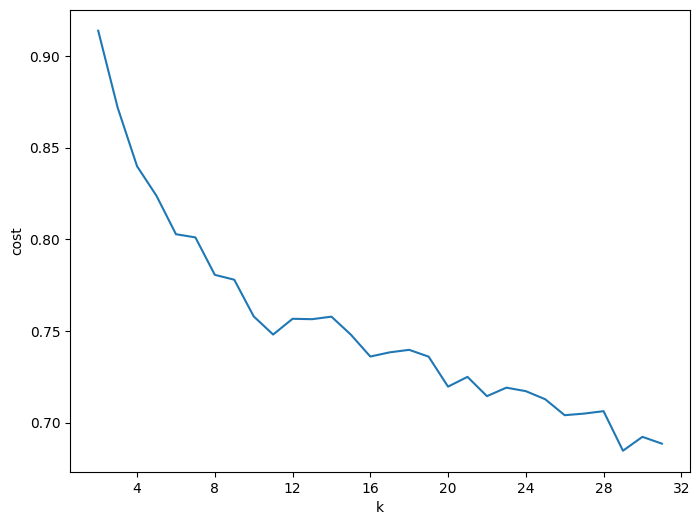

In [ ]:
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sbs
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1,1, figsize =(8,6))
ax.plot(range(2,32),cost[1:31])
ax.set_xlabel('k')
ax.set_ylabel('cost')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

#Scale the input data with 0 mean unit(1) variance

In [ ]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol="features", outputCol="features_std", withStd=True, withMean=True)
scalerModel = scaler.fit(assembled)
scaledData = scalerModel.transform(assembled)

In [ ]:
kmean = KMeans(k = number_of_clusters,featuresCol="features_std")

In [ ]:
model_std = kmean.fit(scaledData)

In [ ]:
prediction_std = model_std.transform(scaledData)

In [ ]:
prediction_std.groupBy('prediction').count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1|18221|
|         6|20948|
|         3|25834|
|         5| 4184|
|         9|12174|
|         4| 9039|
|         8| 8258|
|         7|10750|
|        10|12781|
|        11|11165|
|         2|18727|
|         0|17828|
+----------+-----+



In [ ]:
evaluator = ClusteringEvaluator()
cost = evaluator.evaluate(prediction_std)
print(cost)

-0.26788175702618316


# Perform elbow plot in the range of 2 - 31

In [ ]:
elbowset = scaledData.select("features_std")
elbowset.persist()

DataFrame[features_std: vector]

In [ ]:
# Evaluate clustering by computing Silhouette score
cost = np.zeros(30)
for k in range(2,31):
    kmeans = KMeans(featuresCol="features_std")\
            .setK(k)\
            .setSeed(1)

    model = kmeans.fit(elbowset)
    prediction=model.transform(elbowset)
    evaluator = ClusteringEvaluator(featuresCol="features_std")
    silhouette = evaluator.evaluate(prediction)
    cost[k-1] = silhouette

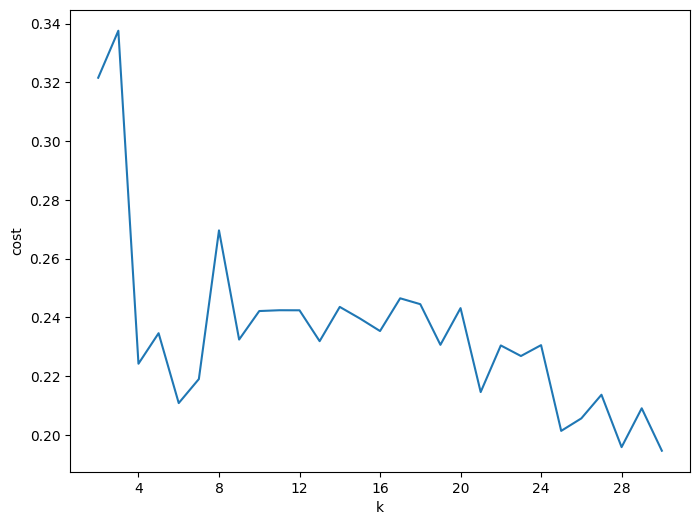

In [ ]:
fig, ax = plt.subplots(1,1, figsize =(8,6))
ax.plot(range(2,31),cost[1:30])
ax.set_xlabel('k')
ax.set_ylabel('cost')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

# Use K-mean with selected K (let's k=12)

In [ ]:
kmeans = KMeans(featuresCol="features_std",k=12, seed=1, maxIter=50)
model = kmeans.fit(scaledData)
transformed = model.transform(scaledData)

In [ ]:
centers = model.clusterCenters()
centers

[array([ 0.58330262, -0.09090642, -0.54231096, -0.35591569, -0.17112952,
        -0.24778652, -0.20903784, -0.12839241, -0.11040326, -1.55922215,
        -0.41890672, -0.30377085, -0.31129507]),
 array([ 1.1091759 , -1.33761363, -1.31647704,  2.0791238 , -0.2628794 ,
        -1.78753982, -0.32174079, -0.68198955, -1.35169494, -0.08574421,
        -0.68282589, -0.30198968, -0.03160914]),
 array([-0.72486179,  0.57818221,  0.70703274, -0.31738169, -0.17017911,
         0.72123126, -0.06647488,  0.10276098,  0.22110114, -0.17270403,
         0.86001343, -0.30451947,  2.40793742]),
 array([ 0.67613029,  0.38718639, -0.37612616, -0.42138424, -0.16476316,
        -0.07033916, -0.12948932,  0.20137304,  0.72363053,  0.64088124,
        -0.63422651, -0.30451947, -0.338566  ]),
 array([ 1.0386799 , -0.56279168, -0.84265661,  0.09440578,  0.06120985,
        -0.58199495, -0.11564719, -0.30278435, -0.43270169,  0.12915754,
        -0.82513253, -0.30208627,  2.61947374]),
 array([-0.99892191, -0.5

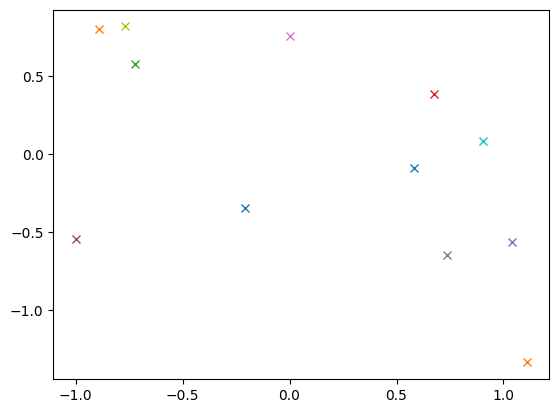

In [ ]:
for k in range(0,12):
    plt.plot(centers[k][0],centers[k][1],'x')


In [ ]:
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType

In [ ]:
compare_df = predictions.select(["id","key","prediction"])
compare_df.printSchema()

root
 |-- id: string (nullable = true)
 |-- key: long (nullable = true)
 |-- prediction: integer (nullable = false)



In [ ]:
# Change "key" to "label"
compare_df = compare_df.withColumnRenamed('key','label')

In [ ]:
#Cast the Column "label" and "prediction" to be Double Type for calculate the accuracy (Previous, it is int)
compare_df = compare_df.withColumn("label", col("label").cast(DoubleType()))
compare_df = compare_df.withColumn("prediction", col("prediction").cast(DoubleType()))

In [ ]:
compare_df.show()

+--------------------+-----+----------+
|                  id|label|prediction|
+--------------------+-----+----------+
|6KbQ3uYMLKb5jDxLF...| 10.0|       8.0|
|6KuQTIu1KoTTkLXKr...|  8.0|       0.0|
|6L63VW0PibdM1HDSB...|  5.0|       0.0|
|6M94FkXd15sOAOQYR...|  1.0|       0.0|
|6N6tiFZ9vLTSOIxkj...| 11.0|       0.0|
|6NxAf7M8DNHOBTmEd...|  6.0|       9.0|
|6O0puPuyrxPjDTHDU...| 11.0|       0.0|
|6OJjveoYwJdIt76y0...|  1.0|       8.0|
|6OaJ8Bh7lsBeYoBmw...|  9.0|       0.0|
|6PrZexNb16cabXR8Q...|  9.0|       0.0|
|6QBInZBkQNIQYU9gG...| 10.0|       9.0|
|6QIONtzbQCbnmWNwn...| 10.0|       0.0|
|6QgdUySTRGVkNo3Kw...|  7.0|       9.0|
|6RvSNoCPBZeTR2LyG...|  5.0|       0.0|
|6Rwn56jcC0TdGQzbR...|  5.0|       7.0|
|6Sdpmree8xpGWaedA...|  7.0|       9.0|
|6T0mZB7p3qzOifdXZ...|  4.0|       0.0|
|6TFuAErGpJ9FpxQQ1...|  4.0|       7.0|
|6UUfiNT82MWBNnmsE...|  5.0|       7.0|
|6Ukl7n0q3Cjd0Og8u...|  4.0|       0.0|
+--------------------+-----+----------+
only showing top 20 rows



# Plot with 3D on the scatter plot

In [ ]:
Cluster_df = prediction.select("features_std","prediction").toPandas()
Cluster_df.head()

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `features_std` cannot be resolved. Did you mean one of the following? [`features`, `prediction`].;
'Project ['features_std, prediction#19898]
+- Project [features#373, UDF(features#373) AS prediction#19898]
   +- Project [features#373]
      +- Project [id#273, name#274, artists#275, duration_ms#276L, release_date#277, year#278L, acousticness#279, danceability#280, energy#281, instrumentalness#282, liveness#283, loudness#284, speechiness#285, tempo#286, valence#287, mode#288L, key#289L, popularity#290L, explicit#291L, artists_index#345, UDF(struct(acousticness, acousticness#279, danceability, danceability#280, energy, energy#281, instrumentalness, instrumentalness#282, liveness, liveness#283, loudness, loudness#284, speechiness, speechiness#285, tempo, tempo#286, valence, valence#287, mode_double_VectorAssembler_da9cdb193e1b, cast(mode#288L as double), popularity_double_VectorAssembler_da9cd

In [ ]:
prediction.groupBy("prediction").count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|        28| 2454|
|        27| 8662|
|        26| 4640|
|        12| 1621|
|        22| 2410|
|         1| 1680|
|        13|32430|
|        16| 1442|
|         6| 1538|
|         3| 1571|
|        20| 9690|
|         5| 1426|
|        19| 2135|
|        15| 4158|
|         9| 2430|
|        17| 3156|
|         4| 5889|
|         8| 7756|
|        23| 7140|
|         7| 3249|
+----------+-----+
only showing top 20 rows



# Evaluation Part (with 3D chart)
### By using ployly library, we can visualize the 12 different clusters.

In [ ]:

cluster_colors = {
    0: '#e6194b',  # red
    1: '#3cb44b',  # green
    2: '#ffe119',  # yellow
    3: '#0082c8',  # blue
    4: '#f58231',  # orange
    5: '#911eb4',  # purple
    6: '#46f0f0',  # cyan
    7: '#f032e6',  # magenta
    8: '#d2f53c',  # lime
    9: '#fabebe',  # pink
    10: '#008080', # teal
    11: '#e6beff'  # lavender
}

In [ ]:
Cluster_df['instrumentalness'] = Cluster_df['features_std'].apply(lambda x: x[1])
Cluster_df['danceability'] = Cluster_df['features_std'].apply(lambda x: x[2])
Cluster_df['energy'] = Cluster_df['features_std'].apply(lambda x: x[3])

colors = Cluster_df['prediction'].map(cluster_colors)

In [ ]:
import plotly.graph_objects as go

In [ ]:
import plotly.io as pio
pio.renderers.default = 'colab'

fig = go.Figure(data = go.Scatter3d(x=Cluster_df['instrumentalness'],
                                    y=Cluster_df['danceability'],
                                    z=Cluster_df['energy'],
                                    mode = 'markers',
                                    marker=dict(
                                                size=1,
                                                color=colors,
                                                colorscale='Viridis',
                                                colorbar=dict(title='Cluster')
                                            )))
fig.update_layout(title = "3D Scatter plot of Music Key by Clusters",
                  scene=dict(xaxis_title = 'instrumentalness',
                             yaxis_title = 'danceability',
                             zaxis_title = 'energy',
                             aspectratio=dict(x=2, y=2, z=1.5)
                             ),
                  width=1000,
                  height=800
                  )
fig.show()

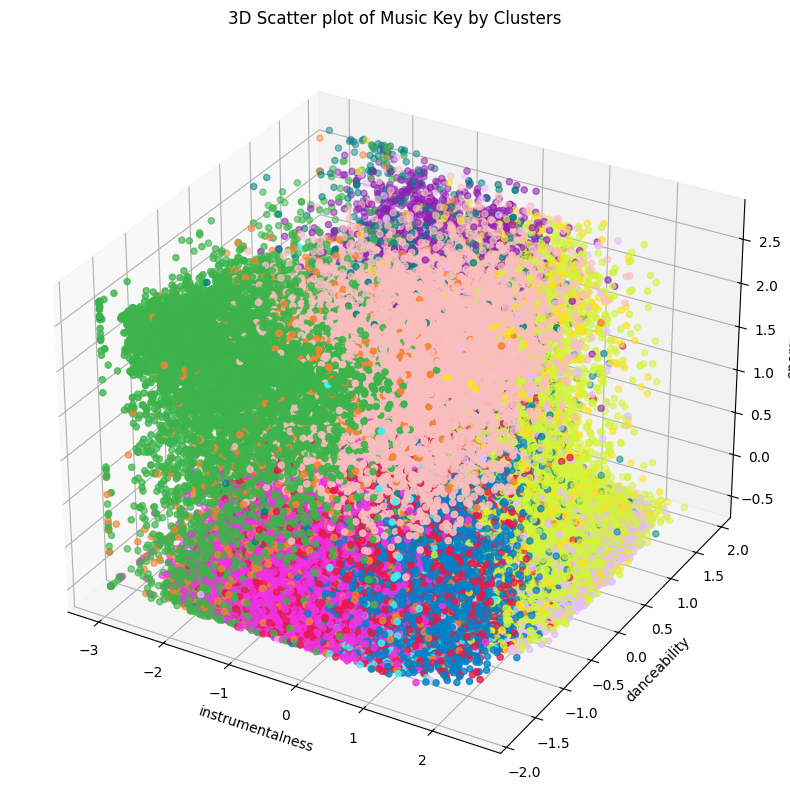

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(Cluster_df['instrumentalness'],
                     Cluster_df['danceability'],
                     Cluster_df['energy'],
                     c = colors,
                     marker = 'o')

ax.set_xlabel('instrumentalness')
ax.set_ylabel('danceability')
ax.set_zlabel('energy')

ax.set_title("3D Scatter plot of Music Key by Clusters")

plt.show()